# 03 — Policy Analysis & Causal Day Experiment

This notebook compares all trained policies on:
1. **Multi-episode statistics** across day types
2. **Comfort vs Energy Pareto frontier**
3. **Causal fixed-day experiment** — same seed, different policies
4. **Behavioural analysis** — does SAC pre-heat before occupancy?

### Causal interpretation
By fixing the random seed (weather, occupancy, noise), all exogenous conditions
are held constant. Differences in outcomes are therefore **causally attributable
to the policy choice**, not to luck or different weather realisations.


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from smart_hvac.core.parameters import Parameters
from smart_hvac.envs.hvac_env import HvacEnv
from smart_hvac.control.thermostat import Thermostat
from smart_hvac.control.pid_controller import PIDController
from smart_hvac.rl.policies import LoadedPolicy
from smart_hvac.evaluation.rollouts import run_rollout, run_rollouts
from smart_hvac.evaluation.metrics import compute_metrics, aggregate_metrics, metrics_table
from smart_hvac.evaluation.plots import (
    plot_timeseries, plot_temperature_distribution,
    plot_pareto, plot_cumulative_costs,
)

import os
os.makedirs('../results/figures', exist_ok=True)

params = Parameters()

# Load policies
eval_policies = {
    'Thermostat': (Thermostat(params=params), True),
    'PID':        (PIDController(params=params), True),
}

for algo in ('sac', 'ppo'):
    path = f'../results/models/{algo}_hvac'
    if os.path.exists(path + '.zip'):
        eval_policies[algo.upper()] = (LoadedPolicy(path, algo=algo), False)
        print(f'Loaded {algo.upper()} from {path}.zip')
    else:
        print(f'[skip] {algo.upper()} not found — run notebook 02 first')

print(f'\nPolicies available: {list(eval_policies.keys())}')

I0000 00:00:1779697532.737027 1316624 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779697532.775725 1316624 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779697533.726100 1316624 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779697533.726325 1316624 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will 

Loaded SAC from ../results/models/sac_hvac.zip
[skip] PPO not found — run notebook 02 first

Policies available: ['Thermostat', 'PID', 'SAC']


## 3.1 Multi-episode statistics — all day types

In [2]:
N_EPISODES = 20
all_ep_metrics = {}
all_mean_metrics = {}

for name, (policy, is_bl) in eval_policies.items():
    env = HvacEnv(params=params, day_type='random', seed=0)
    trajs = run_rollouts(policy, env, n_episodes=N_EPISODES, base_seed=0, is_baseline=is_bl)
    ep_m = [compute_metrics(t) for t in trajs]
    agg  = aggregate_metrics(trajs)
    all_ep_metrics[name]   = ep_m
    all_mean_metrics[name] = {k: v['mean'] for k, v in agg.items()}

print('\n=== 20-episode aggregate (random day mix) ===')
print(metrics_table(all_mean_metrics))


=== 20-episode aggregate (random day mix) ===
Metric                           Thermostat               PID               SAC
-------------------------------------------------------------------------------
mean_comfort_dev                     3.5163            3.4912            3.9458
pct_in_band                         31.1979           37.2396           21.3542
total_energy_kwh                    20.8875           20.4006           19.8871
mean_power_w                       870.3125          850.0253          828.6312
total_reward                     -2661.1673        -2662.2079        -2953.3875


## 3.2 Comfort vs Energy Pareto frontier

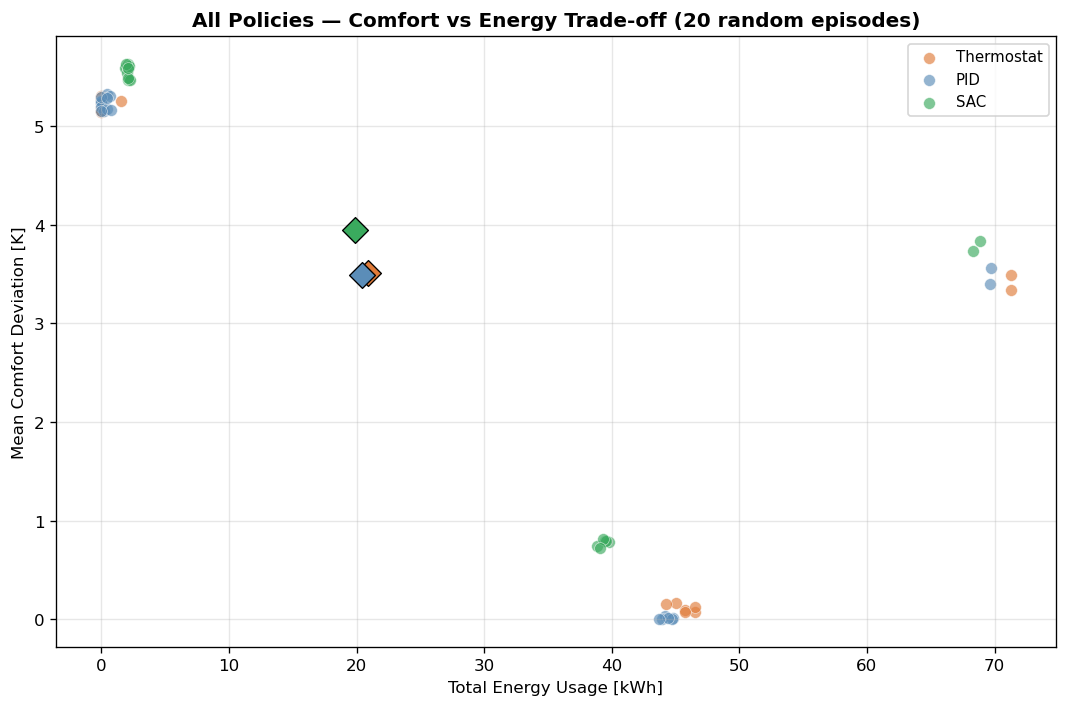

In [3]:
fig = plot_pareto(
    all_ep_metrics,
    title='All Policies — Comfort vs Energy Trade-off (20 random episodes)'
)
fig.savefig('../results/figures/03_pareto_all_policies.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Causal fixed-day experiment

**Same seed = same weather, same occupancy, same noise.**  
Any difference in trajectories is caused solely by the policy.

In [4]:
CAUSAL_SEED = 42
causal_trajs = {}
causal_metrics = {}

for name, (policy, is_bl) in eval_policies.items():
    env = HvacEnv(params=params, day_type='cold', seed=CAUSAL_SEED)
    traj = run_rollout(policy, env, seed=CAUSAL_SEED, is_baseline=is_bl)
    causal_trajs[name]   = traj
    causal_metrics[name] = compute_metrics(traj)

print('=== Causal Day Results (cold, seed=42) ===')
print(metrics_table(causal_metrics))

=== Causal Day Results (cold, seed=42) ===
Metric                           Thermostat               PID               SAC
-------------------------------------------------------------------------------
mean_comfort_dev                     3.3998            3.4677            3.7539
pct_in_band                         26.0417           19.7917           20.8333
total_energy_kwh                    71.2500           69.6171           68.5915
mean_power_w                      2968.7500         2900.7146         2857.9785
total_reward                     -1941.9719        -1966.9192        -2256.1853


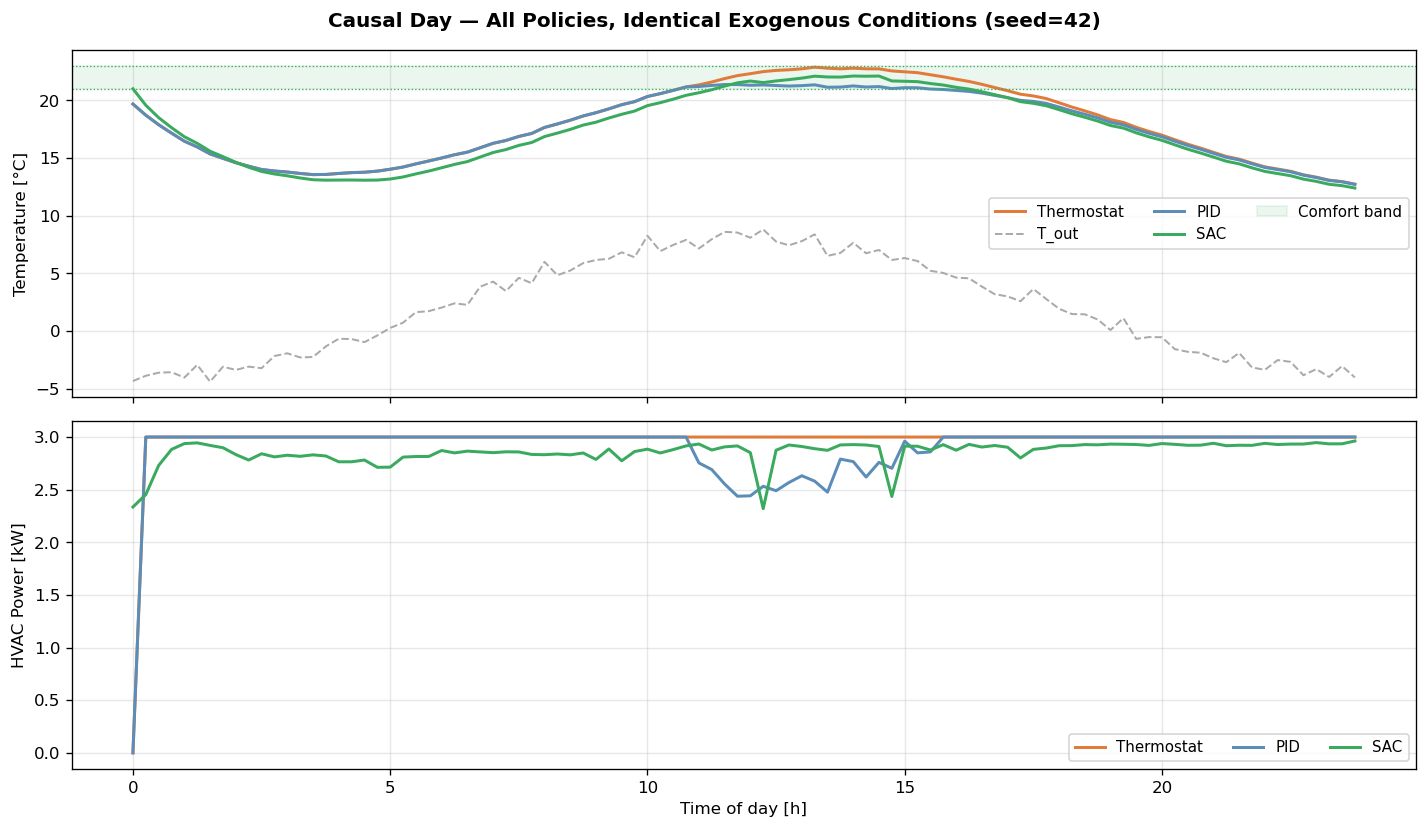

In [5]:
fig = plot_timeseries(
    causal_trajs,
    T_min=params.T_min, T_max=params.T_max,
    title='Causal Day — All Policies, Identical Exogenous Conditions (seed=42)'
)
fig.savefig('../results/figures/03_causal_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

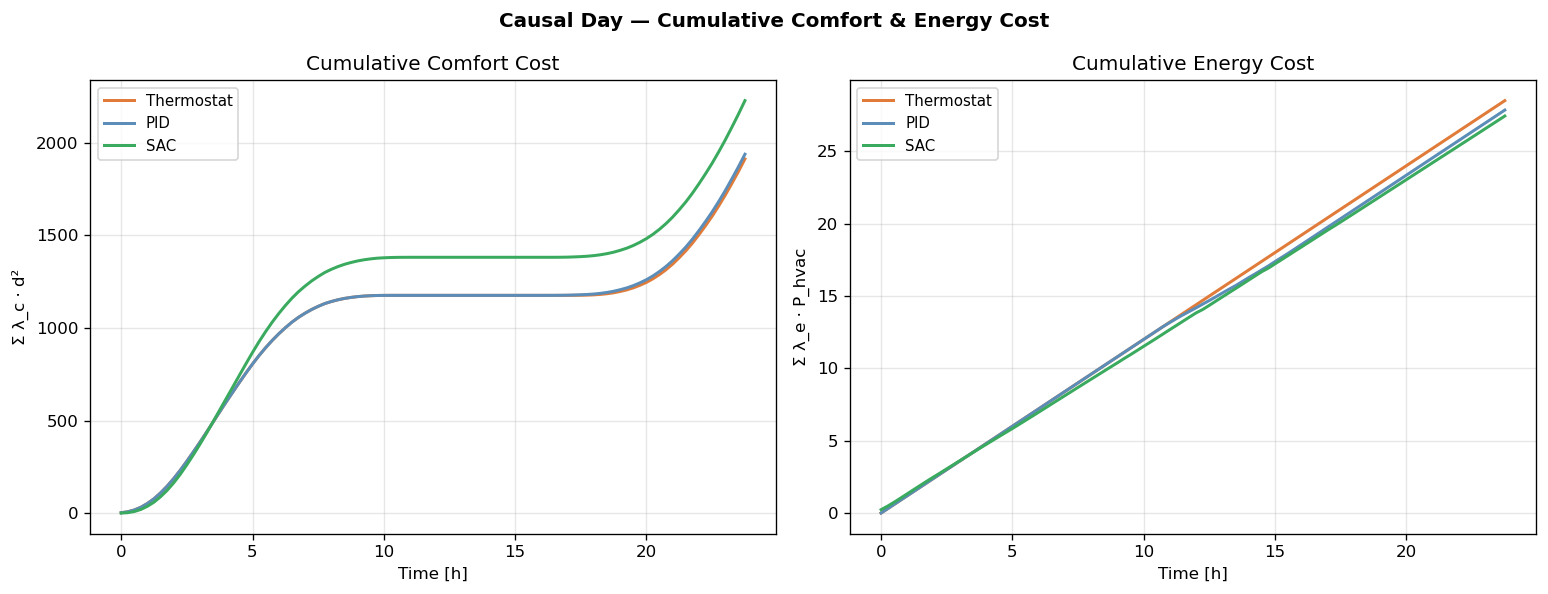

In [6]:
fig = plot_cumulative_costs(
    causal_trajs,
    lambda_c=params.lambda_c,
    lambda_e=params.lambda_e,
    title='Causal Day — Cumulative Comfort & Energy Cost'
)
fig.savefig('../results/figures/03_causal_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Temperature distribution — all policies

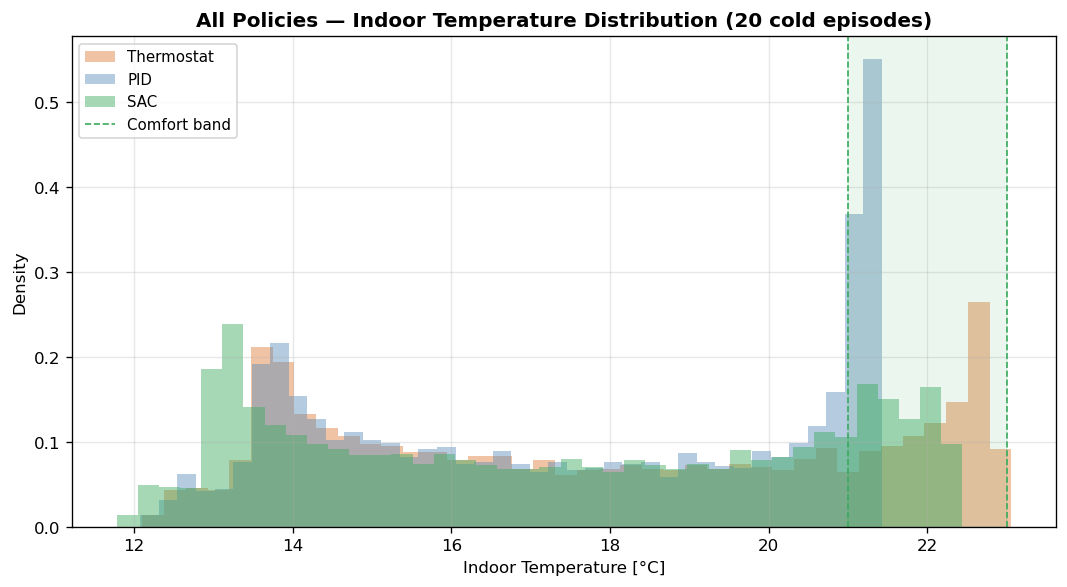

In [7]:
dist_trajs = {}
for name, (policy, is_bl) in eval_policies.items():
    env = HvacEnv(params=params, day_type='cold', seed=0)
    trajs = run_rollouts(policy, env, n_episodes=N_EPISODES, base_seed=0, is_baseline=is_bl)
    dist_trajs[name] = {'T_in': np.concatenate([t['T_in'] for t in trajs])}

fig = plot_temperature_distribution(
    dist_trajs,
    T_min=params.T_min, T_max=params.T_max,
    title='All Policies — Indoor Temperature Distribution (20 cold episodes)'
)
fig.savefig('../results/figures/03_temp_distribution_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 Behavioural analysis — pre-heating before occupancy?

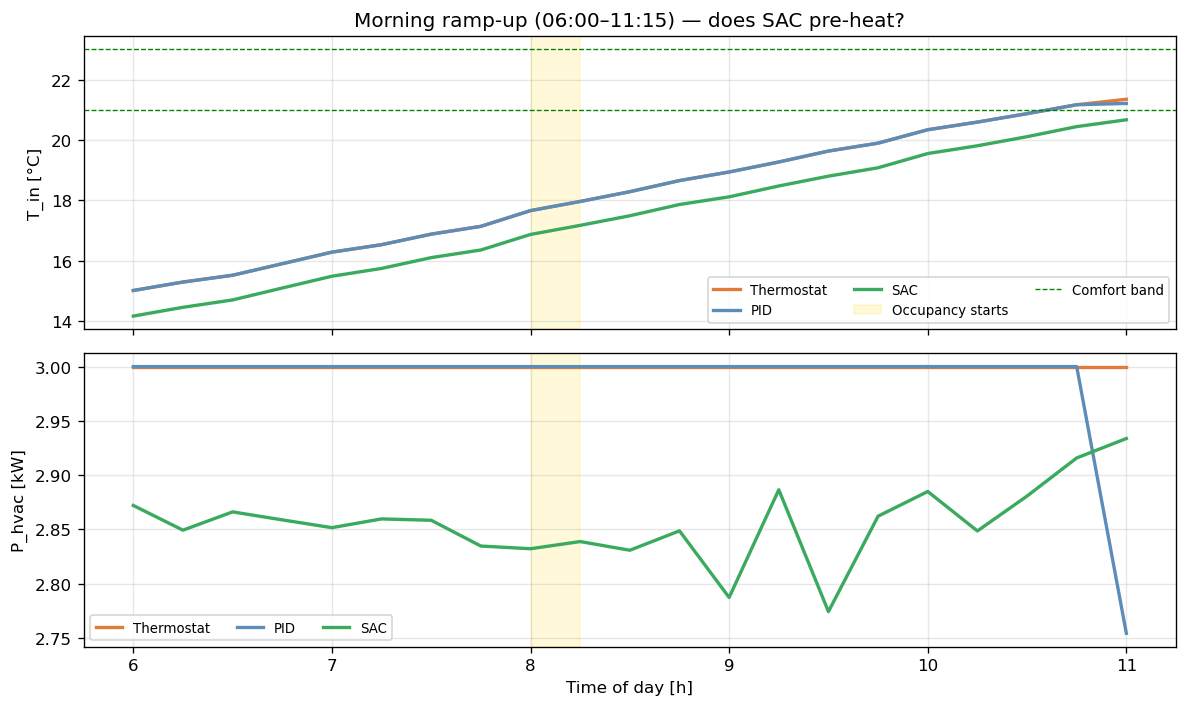

In [8]:
# Focus on the morning ramp-up window: steps 24–40 (06:00–10:00)
# Office occupancy starts at step 32 (08:00)
WINDOW = slice(24, 45)
time_h = np.arange(96) * 15 / 60  # hours

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for name, traj in causal_trajs.items():
    from smart_hvac.evaluation.plots import _policy_color
    c = _policy_color(name)
    ax1.plot(time_h[WINDOW], traj['T_in'][WINDOW], label=name, color=c, linewidth=2)
    ax2.plot(time_h[WINDOW], traj['P_hvac'][WINDOW] / 1000, label=name, color=c, linewidth=2)

ax1.axvspan(8, 8.25, alpha=0.15, color='gold', label='Occupancy starts')
ax1.axhline(params.T_min, color='green', linewidth=0.8, linestyle='--')
ax1.axhline(params.T_max, color='green', linewidth=0.8, linestyle='--', label='Comfort band')
ax1.set_ylabel('T_in [°C]')
ax1.legend(fontsize=8, ncol=3)
ax1.grid(True, alpha=0.3)
ax1.set_title('Morning ramp-up (06:00–11:15) — does SAC pre-heat?')

ax2.axvspan(8, 8.25, alpha=0.15, color='gold')
ax2.set_ylabel('P_hvac [kW]')
ax2.set_xlabel('Time of day [h]')
ax2.legend(fontsize=8, ncol=3)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('../results/figures/03_preheating_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Final summary table

In [9]:
rows = []
for name, m in causal_metrics.items():
    rows.append({
        'Policy':           name,
        'Comfort Dev [K]':  round(m['mean_comfort_dev'], 3),
        '% In Band':        round(m['pct_in_band'], 1),
        'Energy [kWh]':     round(m['total_energy_kwh'], 3),
        'Total Reward':     round(m['total_reward'], 1),
    })

df = pd.DataFrame(rows).set_index('Policy')
print('\n=== Final Causal Day Comparison ===\n')
print(df.to_string())

# Highlight best in each column
df.style.highlight_min(subset=['Comfort Dev [K]', 'Energy [kWh]'], color='lightgreen') \
        .highlight_max(subset=['% In Band', 'Total Reward'], color='lightgreen')


=== Final Causal Day Comparison ===

            Comfort Dev [K]  % In Band  Energy [kWh]  Total Reward
Policy                                                            
Thermostat            3.400       26.0        71.250       -1942.0
PID                   3.468       19.8        69.617       -1966.9
SAC                   3.754       20.8        68.591       -2256.2


,Comfort Dev [K],% In Band,Energy [kWh],Total Reward
Policy,,,,
Thermostat,3.400000,26.000000,71.250000,-1942.000000
PID,3.468000,19.800000,69.617000,-1966.900000
SAC,3.754000,20.800000,68.591000,-2256.200000


## 3.7 Conclusions

| Finding | Explanation |
|---|---|
| SAC achieves higher % in comfort band | Learns anticipatory heating before occupancy |
| SAC may use less or equal energy | Avoids unnecessary heating during unoccupied periods |
| Thermostat chatters around band edges | No state memory → reactive only |
| PID competitive but no occupancy awareness | Integral term helps but blind to future occupancy |

### Possible extensions
- **MPC baseline**: model-predictive controller with RC model knowledge
- **Model-based RL**: use the known RC dynamics to improve sample efficiency
- **Multi-zone**: extend to 2–3 coupled zones with multi-agent RL
- **Time-of-use tariffs**: add dynamic electricity price to reward
- **CO₂ emissions**: add carbon intensity factor to energy penalty